<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
723
(302, 14)


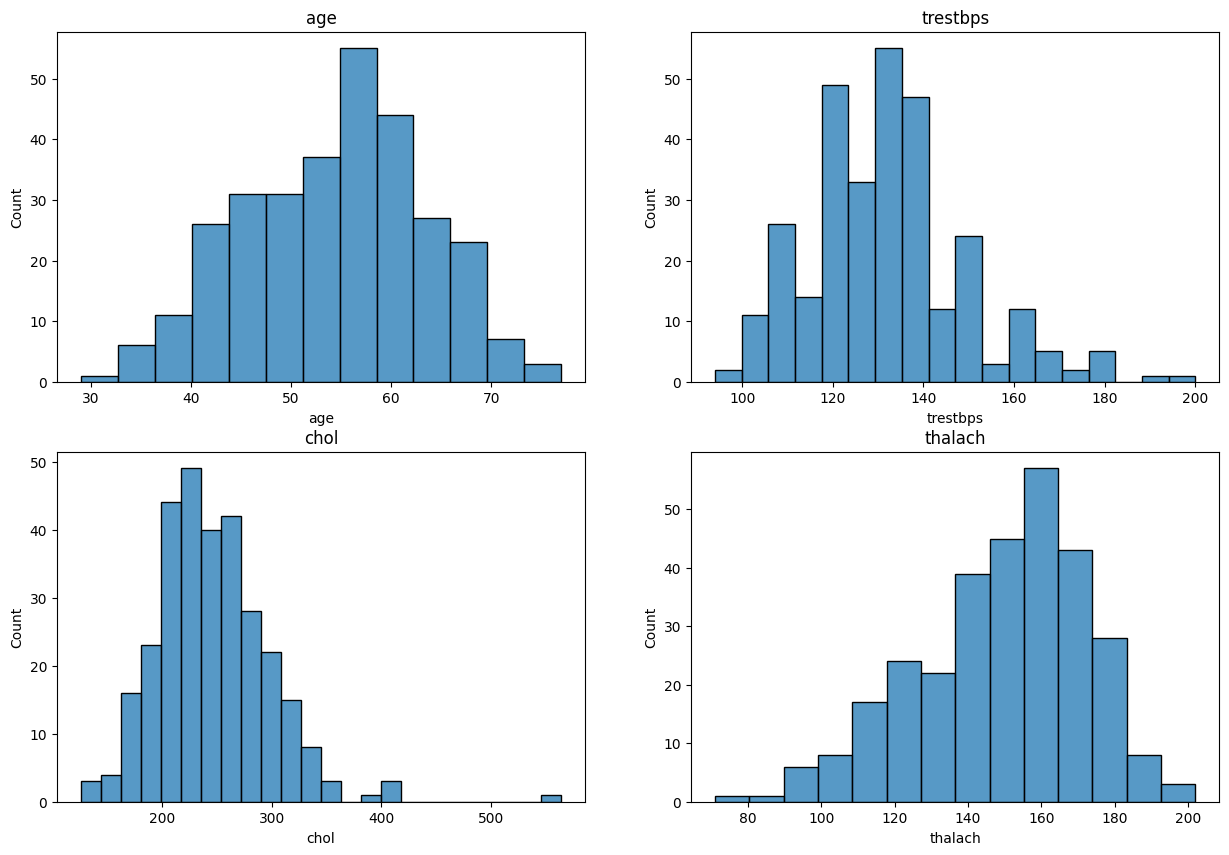

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Load the data
df = pd.read_csv('/content/heart.csv')
df.head()
df.shape
df.info()
print(df.duplicated().sum())

# See the actual duplicate rows
df[df.duplicated()].head(10)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)
df.describe()

#univariate
fig,axes = plt.subplots(2,2,figsize=(15,10))
sns.histplot(df['age'],ax=axes[0,0])
sns.histplot(df['trestbps'],ax=axes[0,1])
sns.histplot(df['chol'],ax=axes[1,0])
sns.histplot(df['thalach'],ax=axes[1,1])

axes[0,0].set_title('age')
axes[0,1].set_title('trestbps')
axes[1,0].set_title('chol')
axes[1,1].set_title('thalach')
plt.show()

#bivariate
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Age vs Target',
                                   'Trestbps vs Target',
                                   'Chol vs Target',
                                   'Thalach vs Target'))

fig.add_trace(go.Box(x=df['target'], y=df['age']), row=1, col=1)
fig.add_trace(go.Box(x=df['target'], y=df['trestbps']), row=1, col=2)
fig.add_trace(go.Box(x=df['target'], y=df['chol']), row=2, col=1)
fig.add_trace(go.Box(x=df['target'], y=df['thalach']), row=2, col=2)

fig.update_layout(title='Heart Disease — Bivariate Analysis',
                  height=700, showlegend=False)
fig.show()

